<a href="https://colab.research.google.com/github/vladgap/Various/blob/main/2D_3D_3D%2B_function_approximation_170526.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
class NN:
    """Creates a two layer neuron network: the hidden layer and the output layer.
       The output layer may be multiple.
       The activation functions of the layers may be set.

       X and T are numpy column vectors or set of column vectors as numpy matrices.
       If the data is pandas dataframe, it should be turned to numpy:
          X=np.array(DataFrame[[x0,x1,...]])
          T=np.array(DataFrame[[t0,...]])
       The same for confidences.

       Attributes:
          layers: A list of layers. [2,3,1] -- 2 inputs, 3 neurons in hidden layer, 1 neuron in output layer
          hidden_activation: Activation function of the hidden layer. 'linear' (by default), 'sigmoid', 'prelu'.
          output_activation: Activation function of the output layer. 'linear' (by default) for regression, 'softmax' for classification.
          Wh, bh, Wo, bo: Matrices of weights.
          JWh, Jbh, JWo, Jbo: Matrices of weight Jacobian."""

    def __init__(self, layers, hidden_activation='linear', output_activation='linear'):
        """Return a new MLP object with the specified parameters.
           layers: A list of layers. [2,3,1] -- 2 inputs, 3 neurons in hidden layer, 1 neuron in output layer
           hidden_activation: Activation function of the hidden layer. 'linear' (by default), 'sigmoid', 'prelu'.
           output_activation: Activation function of the output layer. 'linear' (by default) for regression, 'softmax' for classification."""
        self.layers = layers
        self.hidden_activation = hidden_activation
        self.output_activation = output_activation
        self.imported = False  # before weights import

    def sigmoid(self, x):
        """Sigmoid activation function."""
        return 1. / (1. + np.exp(-x))

    def sigmoid_deriv(self, x):
        """Sigmoid derivative function."""
        return x * (1 - x)

    def PReLU(self, x):
        """Parametric ReLU activation function.
           Parameter = 0.001"""
        np.copyto(x, np.maximum(0.001 * x, x))
        return x

    def PReLU_deriv(self, x):
        """Parametric ReLU derivative function:
           Matrix with ones for positives and 0.001s for negatives."""
        y = np.ones_like(x)
        y[x < 0] = 0.001
        return y

    def softmax(self, x):
        """Softmax activation function"""
        return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

    def hidden_activations(self, X):
        """Compute the hidden activations H.
           self.hidden_activation may be 'linear' (default), 'sigmoid' or 'prelu'."""
        Zh = (X @ self.Wh) + self.bh
        if self.hidden_activation == 'sigmoid':
            return self.sigmoid(Zh)
        elif self.hidden_activation == 'prelu':
            return self.PReLU(Zh)
        return Zh  # default (linear) activation

    def output_activations(self, H):
        """Compute the output Y.
           self.output_activation may be 'linear' (default) or 'softmax'."""
        Zo = (H @ self.Wo) + self.bo
        if self.output_activation == 'softmax':
            return self.softmax(Zo)
        if self.output_activation == 'linear':
            return Zo
        return Zo  # default

    def __run(self, X):
        """Runs the input X vectors of input layer, returns the Y vectors of output layer."""
        return self.output_activations(self.hidden_activations(X))

    def loss(self, Y, T, confidences=None):
        """Loss function.
           Regression: MSE (output_activation -- 'linear').
           Classification: cross-entropy (output_activation -- 'softmax')."""
        SE = (Y - T) ** 2  # MSE
        abs_err = np.abs(Y - T)  # ABS
        confidences = np.ones_like(T) if confidences is None else confidences
        confidences = np.minimum(confidences, 1e4)  # avoid confidences=inf (variance=0)
        weighted_SE = SE * confidences
        MSE = weighted_SE.sum() / Y.shape[0]
        if self.output_activation == 'linear':
            return MSE
        if self.output_activation == 'softmax':
            return - (T * np.log(Y)).sum()  # softmax layer with corresponding cross-entropy loss function
        return MSE  # default

    def error_output(self, Y, T):
        """Error function at the output"""
        return (Y - T) * self.confidences  # same for softmax and MSE

    def gradient_weight_out(self, H, Eo):
        """Gradients for the weight parameters at the output layer"""
        return H.T @ Eo

    def gradient_bias_out(self, Eo):
        """Gradients for the bias parameters at the output layer"""
        return np.sum(Eo, axis=0, keepdims=True)

    def error_hidden(self, H, Eo):
        """Error at the hidden layer.
        H * (1-H) * (E . Wo^T) for sigmoid
        [1 for pos, 0.001 for neg] * (E . Wo^T) for PReLU
        (E . Wo^T) for linear (default)."""
        if self.hidden_activation == 'sigmoid':
            return np.multiply(self.sigmoid_deriv(H), (Eo @ self.Wo.T))
        if self.hidden_activation == 'prelu':
            return np.multiply(self.PReLU_deriv(H), (Eo @ self.Wo.T))
        if self.hidden_activation == 'linear':
            return (Eo @ self.Wo.T)
        return (Eo @ self.Wo.T)  # default

    def gradient_weight_hidden(self, X, Eh):
        """Gradient for the weight parameters at the hidden layer"""
        return X.T @ Eh

    def gradient_bias_hidden(self, Eh):
        """Gradient for the bias parameters at the output layer"""
        return np.sum(Eh, axis=0, keepdims=True)

    def generate_weights(self, init_var=0.1):
        # Initialize hidden layer parameters
        bh = np.random.randn(1, self.layers[1]) * init_var
        Wh = np.random.randn(self.layers[0], self.layers[1]) * init_var
        # Initialize output layer parameters
        bo = np.random.randn(1, self.layers[2]) * init_var
        Wo = np.random.randn(self.layers[1], self.layers[2]) * init_var
        return Wh, bh, Wo, bo

    def get_gradients(self, X, T):
        """Update the network parameters over 1 iteration."""
        # Compute the output of the network
        H = self.hidden_activations(X)
        Y = self.output_activations(H)
        # Compute the gradients of the output layer
        Eo = self.error_output(Y, T)
        self.JWo = self.gradient_weight_out(H, Eo)
        self.Jbo = self.gradient_bias_out(Eo)
        # Compute the gradients of the hidden layer
        Eh = self.error_hidden(H, Eo)
        self.JWh = self.gradient_weight_hidden(X, Eh)
        self.Jbh = self.gradient_bias_hidden(Eh)

    def update_momentum(self, X, T, Ms, lr_decay, momentum_term):
        self.get_gradients(X, T)
        Js = [self.JWh, self.Jbh, self.JWo, self.Jbo]
        return [momentum_term * M - lr_decay * J
                for M, J in zip(Ms, Js)]

    def update_weights(self, Ms):
        Ws = [self.Wh, self.bh, self.Wo, self.bo]
        return [P + M for P, M in zip(Ws, Ms)]

    def fit(self, X, T, epochs, confidences=None, X_valid=[], T_valid=[], learning_rate=0.01, learning_rate_decay=0, momentum_term=0.9,
            init_var=0.1, repeat=False):
        """Run backpropagation:
              1. Initilizes weights matrices (if repeat is False)
              2. Creates list of losses and calculates initial loss by rinning self.loss() for train data and validation data (if present)
              3. Creates lists of weight matrices and puts initial matrices
              4. Starts epoch iterations for weights and loss update
                a. Calculates learning rate decay:
                   lr_decay = learning_rate / (1 + learning_rate_decay * epoch)
                   learning_rate_decay = 0 in case of constant learning rate
                b. Runs update_momentum() function, which calls get_gradients() function.
                   get_gradients() calculates H, Y, Eo, Eh and returns weights' Jacobians: self.JWh, self.Jbh, self.JWo, self.Jbo
                   update_momentum() returns list of momentums and replaces the previous ones
                c. Runs update_weights() which returns new weight matrices and replaces the previous ones
                d. Calculates loss and addes to the list of losses for train data and validation data (if present)
                e. New weight matrices are added to their lists
              5. Lists of weight matrices are turned to .self numpy arrays for better slicing option

           epochs: int number of epochs
           X and T are numpy column vectors or set of column vectors as numpy matrices.
           If the data is pandas dataframe, it should be turned to numpy:
              X=np.array(DataFrame[[x0,x1,...]])
              T=np.array(DataFrame[[t0,...]])
           confidences: 1/variances. None by default. If present, the function calculates the confidence interval of the loss.
           learning_rate: learning rate, 0.01 by default
           learning_rate_decay: learning rate decay, 0 by default, integer or float
           momentum_term: momentum term, 0.9 by default, 0 for simple gradiend descent
           init_var: initial variance of generated weights, multiplies np.random.randn(), 0.1 by default
           repeat: False -- new weights are generated,
                   True -- old weights are used from previous fit() or import_weights()

           The results are:
           self.loss_list -- list of floats
           self.valid_loss_list -- list of floats (if validation data is present)
           """
        # Calculate scale data: mean and std
        scaler_X = preprocessing.StandardScaler().fit(X)
        scaler_T = preprocessing.StandardScaler().fit(T)
        self.scaler_X, self.scaler_T = scaler_X, scaler_T
        self.mean_X, self.std_X = scaler_X.mean_, scaler_X.scale_
        self.mean_T, self.std_T = scaler_T.mean_, scaler_T.scale_
        X = scaler_X.transform(X)
        T = scaler_T.transform(T)
        if len(X_valid) > 0:
            X_valid = scaler_X.transform(X_valid)
            T_valid = scaler_T.transform(T_valid)

        if not repeat:
            self.Wh, self.bh, self.Wo, self.bo = self.generate_weights(init_var)
        if self.imported:  # in case of weights import
            self.Wh = np.diag(self.std_X) @ self.Wh_export
            self.bh = self.bh_export + self.mean_X @ self.Wh_export
            self.Wo = self.Wo_export @ np.diag(1/self.std_T)
            self.bo = (self.bo_export - self.mean_T) @ np.diag(1/self.std_T)

        Ms = [np.zeros_like(M) for M in [self.Wh, self.bh, self.Wo, self.bo]]  # Momentums initialization

        # Run backpropagation
        confidences = np.ones_like(T) if confidences is None else np.array(confidences,dtype=np.float64)
        self.confidences = np.minimum(confidences, 1e4)  # avoid confidences=inf (variance=0)

        self.loss_list = [self.loss(self.__run(X), T, confidences)]
        self.valid_loss_list = [self.loss(self.__run(X_valid), T_valid)] if len(X_valid) > 0 else []

        for i in range(epochs):
            # Compute learning rate decay
            lr_decay = learning_rate / (1 + learning_rate_decay * i)

            # Update the momentums and weights
            Ms = self.update_momentum(X, T, Ms, lr_decay, momentum_term)
            self.Wh, self.bh, self.Wo, self.bo = self.update_weights(Ms)

            # Append loss
            self.loss_list.append(self.loss(self.__run(X), T, confidences))
            if len(X_valid) > 0:
                self.valid_loss_list.append(self.loss(self.__run(X_valid), T_valid))

        # Calculate export weights, considering scale
        self.Wh_export = np.diag(1/self.std_X) @ self.Wh
        self.bh_export = self.bh - self.mean_X @ (np.diag(1/self.std_X) @ self.Wh)
        self.Wo_export = self.Wo @ np.diag(self.std_T)
        self.bo_export = self.bo @ np.diag(self.std_T) + self.mean_T

    def export_weights(self):
        """
        return [self.Wh.tolist(), self.bh.tolist(), self.Wo.tolist(), self.bo.tolist()]
        Arranges weights without word "array", in a way that makes possible copy/paste and import as self.import_weights().
        """
        return [self.Wh_export.tolist(), self.bh_export.tolist(), self.Wo_export.tolist(), self.bo_export.tolist()]

    def export_weights_as_numpy(self):
        return [self.Wh_export, self.bh_export, self.Wo_export, self.bo_export]

    def export_weights_as_pandas(self):
        a=[self.Wh_export.tolist(), self.bh_export.tolist(), self.Wo_export.tolist(), self.bo_export.tolist()]
        b=pd.DataFrame()
        for i in a:
            b=pd.concat([b,pd.DataFrame(i)], axis=0)
        return b

    def print_weights(self):
        print('Layers (input, hidden, output): ', self.layers, self.hidden_activation, self.output_activation)
        print('Hidden layer weights: ', self.Wh_export.tolist())
        print('Hidden layer biases: ', self.bh_export.tolist())
        print('Outlet layer weights: ', self.Wo_export.tolist())
        print('Outlet layer biases: ', self.bo_export.tolist())

    def import_weights(self, weights):
        """
        Puts values to Wh, bh, Wo and bo from the list of lists as it is from self.export_weights().
        Flags that weights were imported, so Wh, bh, Wo and bo will be calculated from them in fit().
        """
        self.Wh_export, self.bh_export, self.Wo_export, self.bo_export = np.array(weights[0]), np.array(weights[1]), np.array(weights[2]), np.array(weights[3])
        self.imported = True

    def hidden_activations_export(self, X):
        """Compute the hidden activations H.
           self.hidden_activation may be 'linear' (default), 'sigmoid' or 'prelu'."""
        Zh = (X @ self.Wh_export) + self.bh_export
        if self.hidden_activation == 'sigmoid':
            return self.sigmoid(Zh)
        elif self.hidden_activation == 'prelu':
            return self.PReLU(Zh)
        return Zh  # default (linear) activation

    def output_activations_export(self, H):
        """Compute the output Y.
           self.output_activation may be 'linear' (default) or 'softmax'."""
        Zo = (H @ self.Wo_export) + self.bo_export
        if self.output_activation == 'softmax':
            return self.softmax(Zo)
        if self.output_activation == 'linear':
            return Zo
        return Zo  # default

    def predict(self, X):
        """Calculates prediction."""
        return self.output_activations_export(self.hidden_activations_export(X))


In [2]:
def CopyPasteToPandas(a):
    if a.startswith('\n'):
        a = a[1:]
    if a.endswith('\n'):
        a = a[:-1]
    rows = a.split('\n')
    data = []
    for row in rows:
        parts = row.split('\t')
        parsed_row = []
        for item in parts:
            item = item.strip()
            try:
                # נסה להמיר ל-int או float
                if '.' in item:
                    parsed_row.append(float(item))
                else:
                    parsed_row.append(int(item))
            except ValueError:
                parsed_row.append(item)
        data.append(parsed_row)
    return data

def CopyPasteToArray(a):
    if a.startswith('\n'):
        b=a[1:]
    else:
        b=a
    if b.endswith('\n'):
        b=b[:-1]
    c=b.replace('\t',',')
    d=c.split('\n')
    f=[]
    for e in d:
        if e.replace(',','').replace('.','').isdigit(): # only digits no letters
            f.append(list(eval(e)))
        else:
            f.append(e.split(','))
    return f

In [3]:
class NN2to1:
  def __init__(self, X, T, mesh, confidences=None, hidden_layers=1, hidden_activation='linear'):
    self.X=X
    self.T=T
    self.mesh=mesh
    self.confidences=confidences
    self.hidden_layers=hidden_layers
    self.hidden_activation=hidden_activation
    self.network=NN(layers=[2,hidden_layers,1], hidden_activation = hidden_activation)
    pd.options.plotting.backend = "plotly"

  def fit_model(self, epochs=1000,  learning_rate = 0.001, momentum_term = 0.95):
    self.network.fit(self.X, self.T, epochs=epochs, confidences=self.confidences, learning_rate = learning_rate, momentum_term = momentum_term)
    print('Initial loss =', self.network.loss_list[0])
    print('Final loss =', self.network.loss_list[-1])
    fig=pd.Series(self.network.loss_list).plot()
    fig.show()

  def import_weights(self,weights):
    self.network.import_weights(weights)

  def export_weights(self):
    print ('Hidden layers:', self.hidden_layers)
    print ('Hidden activation:', self.hidden_activation)
    print ('Loss:', self.network.loss_list[-1],'\n')
    return self.network.export_weights()

  def print_weights(self):
    self.network.print_weights()

  def show(self):
    self.predics=self.network.predict(self.X)
    self.errors=(self.predics[:,0]-self.T[:,0])/self.T[:,0]*100
    self.mesh_predics=self.network.predict(self.mesh)
    self.__plot()

  def __plot(self):
    fig = make_subplots(rows=1, cols=2, subplot_titles=('Errors','Model'), column_widths=[0.5, 0.5],
                     specs=[[{"secondary_y": True}, {"type": "scene"}]])

    fig.add_trace(go.Scatter(x=self.T[:,0] , y=self.predics[:,0], mode='markers', marker_size=4, name='Predics', marker_color='black' ), 1, 1)
    fig.add_trace(go.Scatter(x=self.T[:,0], y=self.T[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),1,1,secondary_y=False)
    fig.add_trace(go.Scatter(x=self.T[:,0] , y=self.errors, mode='markers', marker_size=4, name='Errors', marker_color='orange' ), 1, 1, secondary_y=True,)

    fig.add_trace(go.Scatter3d(x=self.X[:,0], y=self.X[:,1], z=self.T[:,0], mode='markers', name='Data'), 1, 2)
    fig.add_trace(go.Scatter3d(x=self.mesh[:,0], y=self.mesh[:,1], z=self.mesh_predics[:,0], mode='markers',marker_color='green', marker_size=1, name='Mesh'),1,2)

    fig.update_layout(title='', autosize=True,
                      # width=1550,
                      height=500,
                      margin=dict(l=0, r=0, b=0, t=30))
    fig.update_scenes(xaxis_title='x', yaxis_title='y',
                      camera_eye=dict(x=0, y=-2.2, z=0),
                      aspectratio=dict(x=1, y=1, z=1)
                      )
    fig.update_scenes(camera_projection_type="orthographic")
    self.fig = fig
    fig.show()

In [4]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from sklearn import preprocessing
import matplotlib.pyplot as plt
import skimage.io as sio
pd.options.plotting.backend = "plotly"

import tensorflow as tf
from tensorflow import keras

In [5]:
# pip install MLNN

In [6]:
# from MLNN import*

In [7]:
!wget -O MLNN.py "https://raw.githubusercontent.com/vladgap/MLNN/main/MLNN_3_2.py"
from MLNN import *

--2026-05-17 19:56:54--  https://raw.githubusercontent.com/vladgap/MLNN/main/MLNN_3_2.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14169 (14K) [text/plain]
Saving to: ‘MLNN.py’

MLNN.py             100%[===================>]  13.84K  --.-KB/s    in 0s      

2026-05-17 19:56:54 (116 MB/s) - ‘MLNN.py’ saved [14169/14169]

Version of MLNN is 3.2


In [8]:
# !wget -O tools.py "https://raw.githubusercontent.com/vladgap/Various/main/tools.py"
# from tools import *
# CopyPasteToPandas CopyPasteToArray print_scaler_data Fit2to1

# f(x) -- simple porabola as is

In [9]:
def func(x):
    y = x**2-1
    return y

In [10]:
x=np.linspace(-1,2,11)
data1=np.array([
               x,
               func(x)
               ]).T
X1=data1[:,[0]]
T1=data1[:,[1]]

## MLNN sigmoid

In [11]:
bp1=NN(layers=[1,2,1], hidden_activation = 'sigmoid')

In [12]:
bp1.fit(X1, T1, epochs=2000, learning_rate = 0.01, momentum_term = 0.95)
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
fig1.show()

Initial loss = 1.0425181045953262
Final loss = 0.0004668342978018152


In [13]:
predics1=bp1.predict(X1)
# predics1

In [14]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

/tmp/ipykernel_14914/4151572383.py:1: RuntimeWarning:

divide by zero encountered in divide



In [15]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error",secondary_y=True, showgrid=False)

fig.show()

In [16]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=bp1.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", secondary_y=True, showgrid=False)

fig.show()

In [17]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 2, 1] sigmoid linear
Hidden layer weights:  [[-1.864164629740505, -2.489962603907804]]
Hidden layer biases:  [[3.322830461396831, -2.752316977243934]]
Outlet layer weights:  [[-7.298494640928993], [3.1735321276916255]]
Outlet layer biases:  [[5.872234530094731]]


In [18]:
bp1.export_weights_as_pandas()

,0,1
0,-1.864165,-2.489963
0,3.322830,-2.752317
0,-7.298495,NaN
1,3.173532,NaN
0,5.872235,NaN


## MLNN pReLU

In [19]:
bp1=NN(layers=[1,2,1], hidden_activation = 'prelu')

In [20]:
bp1.fit(X1, T1, epochs=2000, learning_rate = 0.0001, momentum_term = 0.98)#, repeat=True)
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
fig1.show()

Initial loss = 1.010188448611339
Final loss = 0.024676850763807448


In [21]:
predics1=bp1.predict(X1)
# predics1

In [22]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

/tmp/ipykernel_14914/4151572383.py:1: RuntimeWarning:

divide by zero encountered in divide



In [23]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error",secondary_y=True, showgrid=False)

fig.show()

In [24]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=bp1.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", secondary_y=True, showgrid=False)

fig.show()

In [25]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 2, 1] prelu linear
Hidden layer weights:  [[1.7121920397654045, 0.35298289481700657]]
Hidden layer biases:  [[-1.027315251739017, 1.0377526096778973]]
Outlet layer weights:  [[1.9292832110583946], [-1.4258574942319062]]
Outlet layer biases:  [[0.6816693242934163]]


In [26]:
bp1.export_weights_as_pandas()

,0,1
0,1.712192,0.352983
0,-1.027315,1.037753
0,1.929283,NaN
1,-1.425857,NaN
0,0.681669,NaN


## TensorFlow

In [27]:
# Модель
model = keras.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(2),
    keras.layers.PReLU(alpha_initializer=keras.initializers.Constant(0.001),trainable=False), # чтобы alpha не менялся при обучении
    # keras.layers.Activation('sigmoid'),
    keras.layers.Dense(1, activation='linear')
])

In [28]:
# Компиляция и обучение
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.98)
model.compile(optimizer=optimizer, loss='mse')
history = model.fit(X1, T1, epochs=2000, verbose=0)

In [29]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=history.history['loss'][20:], name=''))
print('Initial loss =', history.history['loss'][0])
print('Final loss =', history.history['loss'][-1])
fig1.show()

Initial loss = 1.3684170246124268
Final loss = 0.07399845123291016


In [30]:
# # Предсказание
predics1 = model.predict(X1)
print("Predictions:", predics1.flatten())
errors1=(predics1-T1)/T1*100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predictions: [-0.6771037  -0.67626184 -0.67542    -0.67457813 -0.67373633 -0.6728945
 -0.53947234  0.30026346  1.1399995   1.9797355   2.819471  ]


/tmp/ipykernel_14914/2740486225.py:4: RuntimeWarning:

divide by zero encountered in divide



In [31]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=model.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", secondary_y=True, showgrid=False)

fig.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [32]:
# # Экспорт весов
all_weights = model.get_weights()
print("\nExported weights:", [w.tolist() for w in all_weights])


Exported weights: [[[0.006930264178663492, 1.5257753133773804]], [-0.0612686425447464, -1.1482794284820557], [0.0010000000474974513, 0.0010000000474974513], [[1.014617919921875], [1.8345509767532349]], [-0.6721287965774536]]


In [33]:
# Экспорт в pandas (аналог export_weights_as_pandas)
df = pd.concat([pd.DataFrame(w) for w in all_weights], axis=0, ignore_index=True)
print("\nWeights as DataFrame:")
df


Weights as DataFrame:


,0,1
0,0.006930,1.525775
1,-0.061269,NaN
2,-1.148279,NaN
3,0.001000,NaN
4,0.001000,NaN
5,1.014618,NaN
6,1.834551,NaN
7,-0.672129,NaN


# f(x) -- simple porabola

In [34]:
def func(x):
    y = x**2-1
    return y

In [35]:
x=np.linspace(-1,2,11)
data1=np.array([
               x,
               func(x)
               ]).T
X1=data1[:,[0]]
T1=data1[:,[1]]

## parameter searching

In [36]:
bp_iter=NN(layers=[1,2,1], hidden_activation = 'prelu')
learning_rate = [0.001, 0.005, 0.01]
momentum_term = [0.8, 0.9, 0.95]
learning_rate_decay = [0]
repeats = range(5)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X1, T1, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                i+=1


total runs: 45
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 

In [37]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
0,0.001,0.8,0.0,0.029780,-0.027910
1,0.001,0.8,0.0,0.412456,0.000000
2,0.001,0.8,0.0,0.412456,0.000000
3,0.001,0.8,0.0,0.048154,-0.000253
4,0.001,0.8,0.0,0.412456,0.000000


In [38]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.2],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [39]:
bp_iter=NN(layers=[1,2,1], hidden_activation = 'prelu')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X1, T1, epochs=1000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [40]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.05], title='Loss')
fig2.show()

In [41]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=relative_delta_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[-0.5, 0.5], title='Relative delta')
fig2.show()

## Loss and relative delta

In [42]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
[fig.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i),secondary_y=False) for i in range(n)]
[fig.add_trace(go.Scatter(y=relative_delta_lists2[i][100:], name=i),secondary_y=True) for i in range(n)]

fig.update_xaxes(title_text="data")
fig.update_yaxes(title_text="loss", secondary_y=False)
fig.update_yaxes(title_text="relative_delta", secondary_y=True, showgrid=False, range=[-0.01, 0.01], tick0=-0.01, dtick=.0025)
fig.update_layout(title='Loss and relative delta')
fig.show()

## best_weights_for_now

In [43]:
best_weights_for_now1=weights_lists2[6]
best_weights_for_now1

[[[0.010489382526011724, -0.6747195266413442]],
 [[-0.07347766913504349, 1.3611514201020887]],
 [[-0.1467662488082539], [-1.4820995984289769]],
 [[1.667351189092467]]]

In [44]:
manual_best_weights_for_now1=[[[-0.9240336746724387, 1.5474530759729979]],
 [[-0.3354721998035503, -1.0381958538361835]],
 [[1.4632580917759122], [1.8102209615672984]],
 [[-0.8999364651838688]]]

 # relu
 # epochs=1000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 0
 # loss = .0091

## fitting best parameters

In [45]:
bp1=NN(layers=[1,2,1], hidden_activation = 'prelu')

In [46]:
# bp1.import_weights(best_weights_for_now1)
bp1.import_weights(manual_best_weights_for_now1)
bp1.fit(X1, T1, epochs=2000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 1, repeat=True)

In [47]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
# fig1.show()

Initial loss = 0.009096634917943805
Final loss = 0.00909439386220425


## prediction

In [48]:
predics1=bp1.predict(X1)
predics1

array([[-0.04286404],
       [-0.4482625 ],
       [-0.85366097],
       [-0.90236972],
       [-0.90193559],
       [-0.90150146],
       [-0.53989347],
       [ 0.30007279],
       [ 1.14003904],
       [ 1.9800053 ],
       [ 2.81997156]])

In [49]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

/tmp/ipykernel_14914/4151572383.py:1: RuntimeWarning:

divide by zero encountered in divide



In [50]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

# Set y-axes titles
fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

In [51]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=bp1.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

In [52]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 2, 1] prelu linear
Hidden layer weights:  [[-0.9245744142905906, 1.5474511543643832]]
Hidden layer biases:  [[-0.33624232621737105, -1.0382429331131158]]
Outlet layer weights:  [[1.4645975872835633], [1.810229448826795]]
Outlet layer biases:  [[-0.8998530935526028]]


In [53]:
bp1.export_weights_as_pandas()

,0,1
0,-0.924574,1.547451
0,-0.336242,-1.038243
0,1.464598,NaN
1,1.810229,NaN
0,-0.899853,NaN


# f(x) -- sigmoids

In [54]:
data=CopyPasteToArray('''
MgCl2	H2O
84.0	65.2
86.9	65.4
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
95.1	64.7
97.8	63.4
98.5	62.4
99.2	60.8
''')
# data
data1=pd.DataFrame(data[1:], columns=data[0])
# data1

In [55]:
X1=np.array(data1)[:,[0]]
T1=np.array(data1)[:,[1]]

## parameter searching

In [56]:
bp_iter=NN(layers=[1,3,1], hidden_activation = 'sigmoid')
learning_rate = [0.01, 0.02, 0.05]
momentum_term = [0.97, 0.98, 0.99]
learning_rate_decay = [0]
repeats = range(5)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X1, T1, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                i+=1


total runs: 45
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 

/tmp/ipykernel_14914/1049604958.py:31: RuntimeWarning:

overflow encountered in exp



41 42 43 44 

In [57]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.sort_values('final_loss').head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
31,0.05,0.97,0.0,9.334629e-09,-0.369432
9,0.01,0.98,0.0,9.878168e-05,-0.308147
19,0.02,0.97,0.0,3.443162e-04,-0.003685
15,0.02,0.97,0.0,3.817559e-04,-0.031005
34,0.05,0.97,0.0,4.208647e-04,-0.014279


In [58]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.01],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [59]:
bp_iter=NN(layers=[1,3,1], hidden_activation = 'sigmoid')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X1, T1, epochs=4000, learning_rate = 0.02, momentum_term = 0.97, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [60]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.05], title='Loss')
fig2.show()

## best_weights_for_now

In [61]:
best_weights_for_now1=weights_lists2[13]
best_weights_for_now1

[[[-1.0076619023630604, 0.7504709111381953, 1.6065732871993952]],
 [[96.07360430153992, -60.71151639385235, -159.31052470550367]],
 [[1.4312462680347804], [1.4952752776271478], [-6.075153566696421]],
 [[62.40701105055892]]]

In [62]:
manual_best_weights_for_now1=[[[1.823900615888569, 0.47404157835206534, -0.6456924684227902]],
 [[-180.80468330302634, -46.213873771598536, 52.9225352668374]],
 [[-4.687426778724141], [-3.1452287722200714], [-1.2470284865353984]],
 [[65.46906403468866]]]

 # 3 sigmoids
 # epochs=1000, learning_rate = 0.02, momentum_term = 0.97, learning_rate_decay = 0
 # loss = 3e-8

## fitting best parameters

In [63]:
bp1=NN(layers=[1,3,1], hidden_activation = 'sigmoid')

In [64]:
bp1.import_weights(best_weights_for_now1)
# bp1.import_weights(manual_best_weights_for_now1)
bp1.fit(X1, T1, epochs=2000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 1, repeat=True)

In [65]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
# fig1.show()

Initial loss = 0.0002601966555922633
Final loss = 0.0002601799199151376


## prediction

In [66]:
predics1=bp1.predict(X1)
# predics1

In [67]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

In [68]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

In [69]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=bp1.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extenden prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_xaxes(title_text="")

fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-1, 1], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.update_layout(
    width=1000, height=1000,
)

fig.show()

In [70]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 3, 1] sigmoid linear
Hidden layer weights:  [[-1.0076360374635165, 0.750489521616524, 1.6065727535289922]]
Hidden layer biases:  [[96.07115481885559, -60.71311346073151, -159.31047702193624]]
Outlet layer weights:  [[1.4312603361789165], [1.4952552829476577], [-6.075153027562718]]
Outlet layer biases:  [[62.407019238282174]]


In [71]:
bp1.export_weights()

[[[-1.0076360374635165, 0.750489521616524, 1.6065727535289922]],
 [[96.07115481885559, -60.71311346073151, -159.31047702193624]],
 [[1.4312603361789165], [1.4952552829476577], [-6.075153027562718]],
 [[62.407019238282174]]]

In [72]:
bp1.export_weights_as_pandas()

,0,1,2
0,-1.007636,0.750490,1.606573
0,96.071155,-60.713113,-159.310477
0,1.431260,NaN,NaN
1,1.495255,NaN,NaN
2,-6.075153,NaN,NaN
0,62.407019,NaN,NaN


# f(x1,x2) -- NN2to1

In [43]:
data=CopyPasteToArray('''
T	NaCl	KCl	MgCl2	TDS	H2O
55	0.0	0.0	100.0	37.6	62.5
55	0.0	0.6	99.4	37.6	62.4
55	0.0	1.7	98.3	37.5	62.5
55	0.0	13.4	86.6	33.2	66.8
55	0.0	30.1	69.9	32.5	67.5
55	0.0	49.4	50.6	29.9	70.1
55	0.0	76.4	23.6	30.6	69.4
83	0.0	0.0	100.0	39.8	60.2
83	0.0	2.6	97.4	38.8	61.2
83	0.0	6.4	93.6	39.5	60.5
83	0.0	16.5	83.5	35.3	64.8
83	0.0	38.3	61.7	33.3	66.7
83	0.0	55.6	44.4	32.9	67.1
83	0.0	79.0	21.0	34.0	66.0
105	0.0	0.0	100.0	43.5	56.5
105	0.0	2.6	97.4	41.8	58.2
105	0.0	9.0	91.0	40.1	59.9
105	0.0	18.5	81.5	37.8	62.2
105	0.0	40.9	59.1	36.3	63.7
105	0.0	60.7	39.3	35.8	64.2
105	0.0	61.0	39.0	35.8	64.2
105	0.0	82.1	17.9	36.4	63.6
105	0.0	100.0	0.0	36.5	63.6
''')
# data
data1=pd.DataFrame(data[1:], columns=data[0])
# data1

In [44]:
fig=go.Figure()
fig.add_trace(go.Scatter3d(x=data1['MgCl2'], y=data1['T'], z=data1['H2O'], mode='markers'))
fig.show()

In [45]:
X1=np.array(data1)[:,[3,0]]
T1=np.array(data1)[:,[5]]

In [47]:
x_range = np.linspace(-10, 110, 31)
y_range = np.linspace(50, 110, 31)
X, Y = np.meshgrid(x_range, y_range)
mesh1 = np.column_stack([X.ravel(), Y.ravel()])

In [48]:
K_Mg=NN2to1(X1, T1, mesh1, confidences=None, hidden_layers=2, hidden_activation='sigmoid')

In [49]:
K_Mg.fit_model(epochs=1000, learning_rate = 0.001, momentum_term = 0.95)

Initial loss = 1.0098752244830151
Final loss = 0.023393267208173363


In [50]:
K_Mg.export_weights()

Hidden layers: 2
Hidden activation: sigmoid
Loss: 0.023393267208173363 



[[[-0.009347061836113137, -0.10368338112704976],
  [0.07204474807991143, -0.0010622133315367928]],
 [[-5.669756496420196, 9.789753127710265]],
 [[-7.647394699964931], [11.557150525097127]],
 [[58.795802988890536]]]

In [51]:
weights=[[[0.010444038376555557, 0.09730388170932779],
  [-0.07863003277668645, 0.0013212725434601285]],
 [[6.132906925334561, -9.391811409254608]],
 [[7.227065199329306], [-12.611130822948276]],
 [[62.99359958834105]]]

K_Mg.import_weights(weights)

In [52]:
K_Mg.show()

In [53]:
K_Mg.print_weights()

Layers (input, hidden, output):  [2, 2, 1] sigmoid linear
Hidden layer weights:  [[0.010444038376555557, 0.09730388170932779], [-0.07863003277668645, 0.0013212725434601285]]
Hidden layer biases:  [[6.132906925334561, -9.391811409254608]]
Outlet layer weights:  [[7.227065199329306], [-12.611130822948276]]
Outlet layer biases:  [[62.99359958834105]]


In [83]:
df=[
[20,60],
[40,60],
[60,60],
[80,60],
[90,60],
[95,60],
]
K_Mg_predics=K_Mg.network.predict(df)
K_Mg_result=pd.concat([pd.DataFrame(df),pd.DataFrame(K_Mg_predics)], axis=1)
K_Mg_result.columns = ['MgCl2', 'T', 'H2O']
K_Mg_result

,MgCl2,T,H2O
0,20,60,69.022719
1,40,60,69.168509
2,60,60,69.011361
3,80,60,67.283980
4,90,60,64.995538
5,95,60,63.534414


In [84]:
K_Mg.network.export_weights_as_pandas()

,0,1
0,0.010444,0.097304
1,-0.078630,0.001321
0,6.132907,-9.391811
0,7.227065,NaN
1,-12.611131,NaN
0,62.993600,NaN


# f(x1,x2) -- x1^3-0.2*x2+5


f=x1^3-0.2*x2+5

In [85]:
data4=[
[0.32,	0.99,	0.77,	0.69,	0.04,	0.37,	0.25,	0.44,	0.42,	0.64,	0.8,],
[0.4,	0.23,	0.22,	0.57,	0.78,	0.69,	0.2,	0.45,	0.17,	0.98,	0.96,],
[4.952768,	5.924299,	5.412533,	5.214509,	4.844064,	4.912653,	4.975625,	4.995184,	5.040088,	5.066144,	5.32,],
]
data4=np.array(data4).T
X4=data4[:,[0,1]]
T4=data4[:,[2]]

In [86]:
# data4[:,0]**3-0.2*data4[:,1]+5

In [87]:
bp4=NN(layers=[2,4,1], hidden_activation = 'prelu')

## fitting

In [88]:
bp4.fit(X4, T4, epochs=1000, learning_rate = 0.01, momentum_term = 0.95, learning_rate_decay = 0, init_var=.1, repeat=False)

In [89]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp4.loss_list[20:], name='sigmoid'))
print('Initial loss =', bp4.loss_list[0])
print('Final loss =', bp4.loss_list[-1])

# fig1.update_yaxes(range=[0, 1])
fig1.show()

Initial loss = 1.0083649566312443
Final loss = 0.029257811651453514


## prediction

In [90]:
predics4=bp4.predict(X4)
predics4[:,0]

array([4.95343272, 5.89466656, 5.44303479, 5.21032968, 4.95279491,
       4.95348323, 4.95332552, 4.95366837, 4.95367721, 5.02785683,
       5.36159717])

## mesh

In [91]:
x_range = np.linspace(-1, 2, 31)
y_range = np.linspace(-1, 2, 31)
X, Y = np.meshgrid(x_range, y_range)
mesh4 = np.column_stack([X.ravel(), Y.ravel()])

In [92]:
mesh_predics4=bp4.predict(mesh4)

## plot

In [93]:
fig_predic=go.Figure()
fig_predic.add_trace(go.Scatter3d(x=data4[:,0], y=data4[:,1], z=data4[:,2], mode='markers', name='data'))
fig_predic.add_trace(go.Scatter3d(x=data4[:,0], y=data4[:,1], z=predics4[:,0], mode='markers', name='predics'))
fig_predic.add_trace(go.Scatter3d(x=x_range, y=y_range, z=mesh_predics4.reshape(X.shape), mode='markers', marker_size=2, name='mesh-predics'))
x=np.linspace(0, 1, 11)
y=np.linspace(0, 1, 11)
x, y = np.meshgrid(x,y)
z=x**3-.2*y+5
fig_predic.add_trace(go.Surface(x=x, y=y, z=z, colorbar_x=0, opacity=0.5, showlegend=True, name='data surface'))
fig_predic.update_scenes(camera_projection_type="orthographic")

fig_predic.show()

# f(x1,x2) - Partial pressure(C,T)

In [94]:
data3=[
[0,	5,	10,	15,	20,	25,	30,	35,	40,	45,	50,	55,	60,	65,	70,	75,	80,	85,	90,	95,	100,	0,	5,	10,	15,	20,	25,	30,	35,	40,	45,	50,	55,	60,	65,	70,	75,	80,	85,	90,	95,	100,	0,	5,	10,	15,	20,	25,	30,	35,	40,	45,	50,	55,	60,	65,	70,	75,	80,	85,	90,	95,	100,0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 65, 70, 75, 80, 85, 90, 95, 100, 75, 80, 85, 90, 95, 100, 80, 85, 90, 95, 100, ],
[20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 130, 130, 130, 130, 130, 130, 130, 130, 140, 140, 140, 140, 140, 140, 150, 150, 150, 150, 150, ],
[23.158,	23.026,	22.763,	22.632,	22.368,	22.105,	21.447,	20.658,	19.474,	18.289,	17.105,	15.526,	13.684,	11.842,	9.737,	7.434,	5.066,	2.842,	1.184,	0.338,	0.038,	41.842,	41.447,	40.789,	39.737,	39.474,	39.211,	38.026,	36.711,	34.474,	32.632,	30.395,	27.5,	24.211,	20.921,	17.237,	13.158,	9.079,	5.197,	2.25,	0.683,	0.078,	72.763,	71.711,	71.316,	70.921,	69.737,	68.421,	66.447,	64.079,	60.658,	56.974,	53.026,	47.368,	42.237,	35.526,	29.605,	23.026,	15.921,	9.145,	4.211,	1.342,	0.158,121.842, 118.421, 115.789, 114.474, 113.158, 110.526, 107.895, 103.947, 98.684, 92.5, 86.579, 77.237, 68.421, 57.895, 48.026, 37.895, 26.184, 15.395, 7.368, 2.447, 0.301, 197.368, 193.421, 192.105, 188.158, 185.526, 184.211, 178.947, 171.053, 161.842, 152.632, 142.105, 126.316, 110.921, 93.421, 78.026, 61.842, 42.895, 25.921, 12.763, 4.382, 0.566, 307.895, 302.632, 300, 296.053, 289.474, 286.842, 277.632, 268.421, 253.947, 239.474, 223.684, 197.368, 175, 146.053, 121.053, 97.368, 68.421, 41.711, 21.316, 7.566, 1.02, 467.105, 463.158, 460.526, 453.947, 448.684, 444.737, 430.263, 409.211, 385.526, 361.842, 338.158, 298.684, 263.158, 221.053, 184.211, 146.053, 102.632, 64.211, 34.211, 12.671, 1.75, 692.105, 686.842, 682.895, 673.684, 665.789, 660.526, 638.158, 615.789, 589.474, 553.947, 517.105, 473.684, 415.789, 348.684, 293.421, 219.737, 157.895, 99.342, 53.947, 20.658, 3, 1000, 993.421, 990.789, 977.632, 967.105, 959.211, 927.632, 901.316, 863.158, 810.526, 756.579, 686.842, 605.263, 510.526, 423.684, 315.789, 227.632, 146.053, 81.579, 32.763, 4.803, 1414.474, 1405.263, 1402.632, 1384.211, 1368.421, 1356.579, 1310.526, 1276.316, 1221.053, 1147.368, 1071.053, 961.842, 817.105, 689.474, 572.368, 447.368, 322.368, 210.526, 122.368, 50.658, 7.632, 1325, 1118.421, 953.947, 797.368, 631.579, 453.947, 300, 178.947, 76.842, 11.842, 1315.789, 1098.684, 868.421, 631.579, 423.684, 259.211, 114.079, 17.237, 1177.632, 861.842, 585.526, 364.474, 165.789, 26.711, 1157.895, 789.474, 503.947, 243.421, 38.816, ]
]
#[C]
#[T]
#[P]
data3=np.array(data3).T

In [95]:
X3=data3[:,[0,1]]
T3=data3[:,[2]]

## parameter searching

In [96]:
bp_iter=NN(layers=[2,4,1], hidden_activation = 'sigmoid')
learning_rate = [0.001, 0.005, 0.01, 0.05]
momentum_term = [0.7, 0.8, 0.9]
learning_rate_decay = [0, 1]
repeats = range(10)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X3, T3, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                if i%25==0 and i>0:
                    print ('\n')
                i+=1


total runs: 240
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 

26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 

51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 

76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 

101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 

126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 

151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 

176 177 178 179 180 

/tmp/ipykernel_14914/1049604958.py:31: RuntimeWarning:

overflow encountered in exp

/tmp/ipykernel_14914/1049604958.py:82: RuntimeWarning:

overflow encountered in square

/tmp/ipykernel_14914/1049604958.py:112: RuntimeWarning:

overflow encountered in matmul

/tmp/ipykernel_14914/1049604958.py:112: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipykernel_14914/3652465319.py:16: RuntimeWarning:

invalid value encountered in scalar divide

/tmp/ipykernel_14914/3652465319.py:16: RuntimeWarning:

invalid value encountered in scalar subtract

/tmp/ipykernel_14914/1049604958.py:31: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

overflow encountered in reduce

/tmp/ipykernel_14914/1049604958.py:82: RuntimeWarning:

overflow encountered in square

/tmp/ipykernel_14914/1049604958.py:112: RuntimeWarning:

overflow encountered in matmul

/tmp/ipykernel_14914/1049604958.py:112: RuntimeWarning:

inva

181 182 183 

/tmp/ipykernel_14914/1049604958.py:31: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

overflow encountered in reduce

/tmp/ipykernel_14914/1049604958.py:82: RuntimeWarning:

overflow encountered in square

/tmp/ipykernel_14914/1049604958.py:112: RuntimeWarning:

overflow encountered in matmul

/tmp/ipykernel_14914/1049604958.py:112: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipykernel_14914/3652465319.py:16: RuntimeWarning:

invalid value encountered in scalar divide

/tmp/ipykernel_14914/3652465319.py:16: RuntimeWarning:

invalid value encountered in scalar subtract

/tmp/ipykernel_14914/1049604958.py:31: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

overflow encountered in reduce

/tmp/ipykernel_14914/1049604958.py:82: RuntimeWarning:

overflow encountered in square

/tmp/ipykernel_14914/1049604958.p

184 185 186 

...

/tmp/ipykernel_14914/1049604958.py:31: RuntimeWarning:

overflow encountered in exp



234 235 236 237 

/tmp/ipykernel_14914/1049604958.py:31: RuntimeWarning:

overflow encountered in exp

/tmp/ipykernel_14914/1049604958.py:31: RuntimeWarning:

overflow encountered in exp



238 239 

/tmp/ipykernel_14914/1049604958.py:31: RuntimeWarning:

overflow encountered in exp



In [97]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
0,0.001,0.7,0.0,0.181494,-0.000016
1,0.001,0.7,0.0,0.181570,-0.000031
2,0.001,0.7,0.0,0.177258,-0.027722
3,0.001,0.7,0.0,0.181511,-0.000060
4,0.001,0.7,0.0,0.053269,-0.073491


In [98]:
output_table.sort_values('final_loss').head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
108,0.005,0.9,0.0,0.006971,-0.015869
85,0.005,0.8,0.0,0.008713,-0.038858
89,0.005,0.8,0.0,0.012362,-0.319042
109,0.005,0.9,0.0,0.013785,-1.629712
84,0.005,0.8,0.0,0.014561,-0.035764


In [99]:
weights_list[82]

[[[0.055933770563739174,
   0.10656526717638556,
   -0.07675856338778346,
   0.11790467611315537],
  [-0.08961544746092592,
   0.01722554961737246,
   0.0837745543770278,
   -0.015772929154091807]],
 [[7.489905246845883,
   -6.574418643629674,
   -6.73402293208728,
   -6.069246463123388]],
 [[-481.4759147773152],
  [1183.1374497372412],
  [961.9459684320948],
  [-1193.1167578054217]],
 [[640.7516450360291]]]

In [100]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.2],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [101]:
bp_iter2=NN(layers=[2,4,1], hidden_activation = 'sigmoid')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter2.fit(X3, T3, epochs=3000, learning_rate = 0.002, momentum_term = 0.9, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter2.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter2.export_weights())
    loss_lists2.append(bp_iter2.loss_list)
    relative_delta_lists2.append(relative_delta)

In [102]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.02])
fig2.show()

In [103]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=relative_delta_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[-0.5, 0.5], title='Relative delta')
fig2.show()

## best_weights_for_now

In [104]:
best_weights_for_now3=weights_lists2[6]
best_weights_for_now3

[[[0.0775361443916489,
   0.07997485255842468,
   0.077831985293031,
   -0.05634175702768682],
  [-0.0904690956095572,
   -0.018420488054507387,
   0.00033428528587741205,
   0.07545157307679545]],
 [[7.172642840228544,
   -2.7000822074237996,
   -3.163286225911575,
   -8.048531518160146]],
 [[-1022.5149886296023],
  [-2037.8619788989233],
  [2026.8847532739665],
  [639.1215955224205]],
 [[1015.8364204269903]]]

In [105]:
manual_best_weights_for_now3=[[[0.07504515021273088,
   0.04349919054952768,
   -0.07558692909280851,
   -0.02248167826143463],
  [-0.020211943131414372,
   0.06089136253332214,
   0.0014136643930529953,
   0.06034090787203026]],
 [[-1.7761206388585942,
   -12.679380024455991,
   2.350432170783746,
   -6.60385978341081]],
 [[-1066.4312080431075],
  [-2198.8201688962586],
  [-1057.0715421631137],
  [2809.2813062238706]],
 [[1072.1489390133559]]]

 # epochs=3000, learning_rate = 0.002, momentum_term = 0.9, learning_rate_decay = 0
 # loss = 0.0063

## fitting best parameters

In [106]:
bp3=NN(layers=[2,4,1], hidden_activation = 'sigmoid')

In [107]:
# bp3.import_weights(best_weights_for_now3)
bp3.import_weights(manual_best_weights_for_now3)
bp3.fit(X3, T3, epochs=10000, learning_rate = 0.03, momentum_term = 0.95, learning_rate_decay = 1, repeat=True)

In [108]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp3.loss_list[20:], name=''))
print('Initial loss =', bp3.loss_list[0])
print('Final loss =', bp3.loss_list[-1])
fig1.show()

Initial loss = 0.006253658024654058
Final loss = 0.006179868276222237


## prediction

In [109]:
predics3=bp3.predict(X3)
# predics3

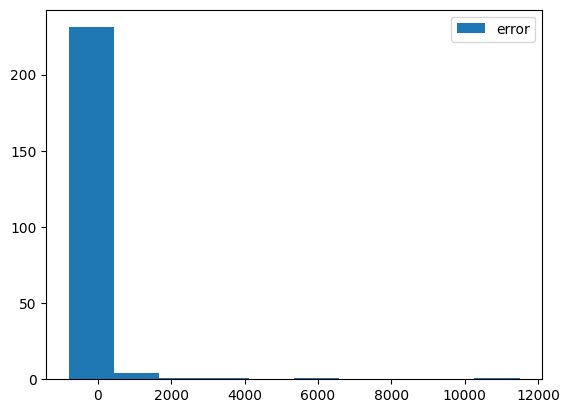

In [110]:
errors3=(predics3-T3)/T3*100
plt.hist(errors3[:,0])
plt.legend(['error'])
plt.show()

In [111]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T3[:,0], y=predics3[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T3[:,0], y=T3[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T3[:,0], y=errors3[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-10, 10], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

## mesh

In [112]:
x_range = np.linspace(0, 100, 31)
y_range = np.linspace(20, 150, 31)
X, Y = np.meshgrid(x_range, y_range)
mesh3 = np.column_stack([X.ravel(), Y.ravel()])

In [113]:
mesh_predics3=bp3.predict(mesh3)

## plot

In [114]:
fig_predic=go.Figure()
fig_predic.add_trace(go.Scatter3d(x=data3[:,0], y=data3[:,1], z=data3[:,2], mode='markers', marker_size=6, name='data'))
fig_predic.add_trace(go.Scatter3d(x=data3[:,0], y=data3[:,1], z=predics3[:,0], mode='markers', marker_size=6, name='predics'))
fig_predic.add_trace(go.Scatter3d(x=x_range, y=y_range, z=mesh_predics3.reshape(X.shape), mode='markers', marker_size=2, name='mesh-predics', visible='legendonly'))

fig_predic.update_layout(
    scene = {
        "xaxis": {"range":[0,100], "nticks": 20},
        "yaxis": {"range":[20,150], "nticks": 20},
        # "zaxis": {"range":[1.1,1.5], "nticks": 6},
        'xaxis_title': '%H3PO4',
        'yaxis_title': 'Temperature, C',
        'zaxis_title': 'Pressure, mbar',
        'camera_eye': {"x": 1.5, "y": -1.5, "z": .7},
        "aspectratio": {"x": 1, "y": 1, "z": 0.6},
        'camera_center': {"x": 0, "y": 0, "z": -0.01}
    },
    width=1000, height=1000,
    margin=dict(l=30, r=30, b=30, t=30),
    title_text=' ',
    title_x=0.5,
)
fig_predic.update_scenes(camera_projection_type="orthographic")
# fig_predic.write_html("Na,K..H2PO4,SO4 density ortho 170522.html")

fig_predic.show()

In [115]:
bp3.print_weights()

Layers (input, hidden, output):  [2, 4, 1] sigmoid linear
Hidden layer weights:  [[0.07497327994352357, 0.04268623244176333, -0.07559815104973795, -0.022014906738150073], [-0.020191997949124577, 0.060563272382290666, 0.0018168104067225767, 0.05989105873946695]]
Hidden layer biases:  [[-1.752948678349736, -12.56339430036215, 2.317601052698076, -6.595154243683369]]
Outlet layer weights:  [[-1080.1214211731185], [-2246.1789899790633], [-1070.7346049621374], [2872.1837122917964]]
Outlet layer biases:  [[1085.6579589373262]]


In [116]:
bp3.export_weights_as_pandas()

,0,1,2,3
0,0.074973,0.042686,-0.075598,-0.022015
1,-0.020192,0.060563,0.001817,0.059891
0,-1.752949,-12.563394,2.317601,-6.595154
0,-1080.121421,NaN,NaN,NaN
1,-2246.178990,NaN,NaN,NaN
2,-1070.734605,NaN,NaN,NaN
3,2872.183712,NaN,NaN,NaN
0,1085.657959,NaN,NaN,NaN


# f(x1,x2,x3)  3-6-3

## data

In [117]:
data5=pd.DataFrame([[3.5432, 44.1176470588235, 39.7307914468193, 1.7787,
        17.1987641606591, 1.03129605623734, 'exp1'],
       [3.5432, 44.1176470588235, 46.7421075844933, 1.61172,
        14.2121524201854, 1.33418381984987, 'exp1'],
       [3.5432, 44.1176470588235, 53.7534237221673, 1.43143,
        11.6947472745292, 1.78559851572739, 'exp1'],
       [3.5432, 44.1176470588235, 60.7647398598413, 1.3224,
        9.75359342915811, 1.8067259420946, 'exp1'],
       [3.61182, 52.5, 33.2044509861419, 1.73556, 26.109391124871,
        1.2784366054216, 'exp2'],
       [3.61182, 52.5, 39.0640599836963, 1.50787, 23.0448383733055,
        1.30063890921072, 'exp2'],
       [3.61182, 52.5, 44.9236689812508, 1.28216, 18.3303085299456,
        1.6396367983226, 'exp2'],
       [3.61182, 52.5, 50.7832779788052, 1.15506, 15.3439153439153,
        1.6793895639359, 'exp2'],
       [3.546, 41.9753086419753, 48.1611135844767, 1.548,
        13.5922330097087, 1.58024190679573, 'exp4'],
       [3.546, 41.9753086419753, 48.1611135844767, 1.548,
        13.5922330097087, 1.58024190679573, 'exp4'],
       [3.546, 41.9753086419753, 55.3852806221482, 1.44056,
        11.2244897959184, 1.75311864093404, 'exp4'],
       [3.546, 41.9753086419753, 62.6094476598198, 1.37192,
        9.61538461538462, 2.33968055882646, 'exp4'],
       [3.15645, 37.3333333333333, 46.223478589122, 1.62281,
        13.6842105263158, 1.26494899078895, 'exp7'],
       [3.15645, 37.3333333333333, 54.3805630460259, 1.48603,
        11.340206185567, 1.53596150580697, 'exp7'],
       [3.15645, 37.3333333333333, 62.5376475029298, 1.39922,
        9.18367346938775, 2.0761800720865, 'exp7'],
       [3.15645, 37.3333333333333, 70.6947319598337, 1.3311,
        7.54716981132076, 2.46615102122547, 'exp7'],
       [3.21264, 48.4375, 35.9576897475555, 1.424, 20.0,
        0.877430345937249, 'exp8'],
       [3.21264, 48.4375, 42.3031644088888, 1.25664, 17.3469387755102,
        1.21143181315366, 'exp8'],
       [3.21264, 48.4375, 48.6486390702222, 1.1736, 14.8514851485148,
        1.51090731456155, 'exp8'],
       [3.21264, 48.4375, 54.9941137315555, 1.0787, 12.8712871287129,
        2.10993639581657, 'exp8'],
       [3.17988, 57.7039274924471, 29.8573774179341, 1.2664,
        28.2178217821782, 0.922752144650929, 'exp9'],
       [3.17988, 57.7039274924471, 35.1263263740401, 1.0569,
        24.3731193580742, 1.1326227604219, 'exp9'],
       [3.17988, 57.7039274924471, 40.3952753301461, 0.9309,
        20.4901960784314, 1.2410533380211, 'exp9'],
       [3.17988, 57.7039274924471, 45.6642242862522, 0.87596,
        18.034188034188, 1.58738143967855, 'exp9']],columns=['SO4_in', 'FA_in', 'DCP_in',	'SO4', 'FA', 'P2O5_norm',	'exp'])

In [118]:
# data5=pd.read_csv('new_dcp_data.csv')
data5.iloc[:,[0,1,2,3,4,5,6]]

,SO4_in,FA_in,DCP_in,SO4,FA,P2O5_norm,exp
0,3.54320,44.117647,39.730791,1.77870,17.198764,1.031296,exp1
1,3.54320,44.117647,46.742108,1.61172,14.212152,1.334184,exp1
2,3.54320,44.117647,53.753424,1.43143,11.694747,1.785599,exp1
3,3.54320,44.117647,60.764740,1.32240,9.753593,1.806726,exp1
4,3.61182,52.500000,33.204451,1.73556,26.109391,1.278437,exp2
5,3.61182,52.500000,39.064060,1.50787,23.044838,1.300639,exp2
6,3.61182,52.500000,44.923669,1.28216,18.330309,1.639637,exp2
7,3.61182,52.500000,50.783278,1.15506,15.343915,1.679390,exp2
8,3.54600,41.975309,48.161114,1.54800,13.592233,1.580242,exp4
9,3.54600,41.975309,48.161114,1.54800,13.592233,1.580242,exp4


In [119]:
X5=np.array(data5)[:,[0,1,2]]
T5=np.array(data5)[:,[3,4,5]]

## parameter searching

In [120]:
bp_iter=NN(layers=[3,6,3], hidden_activation = 'prelu')
learning_rate = [0.001, 0.005, 0.01]
momentum_term = [0.8, 0.9, 0.95]
learning_rate_decay = [0]
repeats = range(10)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X5, T5, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], bp_iter.loss_list[-2] - bp_iter.loss_list[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                if i%25==0 and i>0:
                    print ('\n')
                i+=1

total runs: 90
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 

26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 

51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 

76 77 78 79 80 81 82 83 84 85 86 87 88 89 

In [121]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'final_loss_gradient'])
output_table.fillna(value = 1.1, inplace = True)
output_table.head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,final_loss_gradient
0,0.001,0.8,0.0,0.094261,0.000017
1,0.001,0.8,0.0,0.099084,0.000010
2,0.001,0.8,0.0,0.090311,0.000034
3,0.001,0.8,0.0,0.087639,0.000039
4,0.001,0.8,0.0,0.079700,0.000019


In [122]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.2],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'final_loss_gradient', values = output_table['final_loss_gradient']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'grey',
    paper_bgcolor = 'beige'
)

fig.show()

## running best parameters

In [123]:
bp_iter=NN(layers=[3,6,3], hidden_activation = 'prelu')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X5, T5, epochs=1000, learning_rate = 0.01, momentum_term = 0.9, learning_rate_decay = 0., repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [124]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.1])
fig2.show()

## best_weights_for_now

In [125]:
best_weights_for_now5=weights_lists2[1]
best_weights_for_now5

[[[0.3438067815331447,
   0.9739937477779997,
   2.789453215682906,
   -0.25804897173493513,
   -2.3155671231891324,
   -0.04397380089547712],
  [-0.1022360827341786,
   -0.025018373640842067,
   -0.006280365961754731,
   -0.17247218426567384,
   0.15475219404372464,
   -0.0038940164746703154],
  [0.02474425687824764,
   0.09138736278421017,
   -0.02055086022159476,
   -0.08688159091958703,
   0.012241414036207855,
   -0.0028677507021689086]],
 [[0.626116731293602,
   -4.3700286163043565,
   -10.795463870600626,
   13.386036531948912,
   0.6865523806847391,
   0.20156558572502364]],
 [[0.1812343520858368, -6.366310688459344, 0.23216493397454066],
  [-0.20382927590338107, -6.189505147285256, 0.4275162643351908],
  [-0.23604579303905127, -8.674850390410436, -0.245619335561749],
  [-0.031152318128303682, -3.24565113942444, -0.11496866998798276],
  [-0.34503758881188074, -1.8937979457247194, 0.12408169451458836],
  [-0.022806487000888432, 0.7994181815689411, -0.014442263549069544]],
 [[2.0

In [126]:
manual_best_weights_for_now5=[[[-5.770180144472877,
   4.616759478993374,
   -2.007530395657822,
   1.6542368618134313,
   2.77985599921204,
   -1.4482357407251305],
  [-0.07585359544944305,
   -0.23171305378911253,
   0.1955011138314071,
   -0.0703969066917363,
   0.08350348230223455,
   0.21421868209013434],
  [0.05100197095290809,
   -1.8448211638369358e-06,
   -0.018117918329962613,
   -0.11633954339975902,
   -0.07511606826776582,
   0.0652220743935945]],
 [[20.70409566519093,
   -6.040976016759572,
   -0.5487937571510327,
   3.1758589584839774,
   -10.465105264758986,
   -6.605858434360696]],
 [[-0.023443275471726078, -1.179400080041876, 0.2386311240981955],
  [-0.08351810644477095, -2.538158513838671, 0.876532932431117],
  [-0.04412830861049429, 4.510403834617611, -0.5685821415010486],
  [0.16921778521259706, 1.1030076491425396, 0.0912839589774025],
  [0.116943040343935, 3.8387641397851007, 0.24122997182300926],
  [-0.14148102693681794, -3.0585969004189417, 0.6688610292497558]],
 [[1.5962597696133378, 15.625753398053307, 0.7485009044794693]]]

 # epochs=1000, learning_rate = 0.01, momentum_term = 0.9, learning_rate_decay = 0.
 # loss = 0.0284

## fitting best parameters

In [127]:
bp5=NN(layers=[3,6,3], hidden_activation = 'prelu')

In [128]:
# bp5.import_weights(best_weights_for_now5)
bp5.import_weights(manual_best_weights_for_now5)
bp5.fit(X5, T5, epochs=10000, learning_rate = 0.005, momentum_term = 0.9, learning_rate_decay = 1., repeat=True)

In [129]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp5.loss_list[20:], name=''))
print('Initial loss =', bp5.loss_list[0])
print('Final loss =', bp5.loss_list[-1])
fig1.show()

Initial loss = 0.038732692167386444
Final loss = 0.03860315093892477


## prediction

In [130]:
predics5=bp5.predict(X5)
predics5

array([[1.7658635617040477, 17.343741698213325, 1.0370710309145181],
       [1.558662689295017, 14.14651179363137, 1.317530460426211],
       [1.4154950373892328, 11.633140807175256, 1.6478804879055133],
       [1.3507906386460211, 10.232755368865584, 1.9522496983714426],
       [1.7319080571459124, 26.610351319862318, 1.2418238429502941],
       [1.5156565471693326, 22.519836412734403, 1.3901852357182398],
       [1.2994050371927497, 18.429321505606424, 1.5385466284861873],
       [1.159342386408865, 14.836646887822894, 1.7282181281072582],
       [1.5723519293375627, 13.41331117235053, 1.5854692962333397],
       [1.5723519293375627, 13.41331117235053, 1.5854692962333397],
       [1.4233978300017094, 11.432736375529636, 1.8544627638957196],
       [1.3510158784893338, 9.704952473540063, 2.225706694629622],
       [1.6147702576449947, 13.655706553314452, 1.267322344379844],
       [1.4868251578905947, 11.603989776081562, 1.5765475902139428],
       [1.4013842692238878, 9.4731293436616

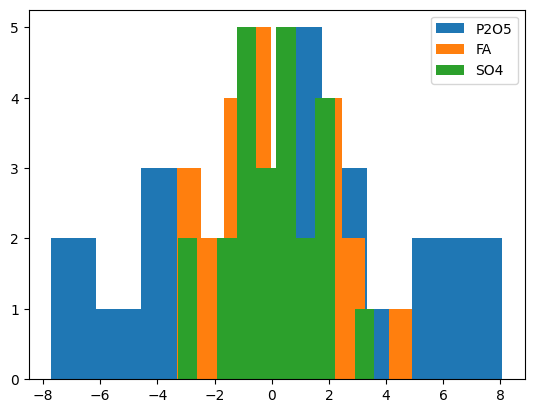

In [131]:
pred=predics5
predics5_y1_vbp=pred[:,0]
error5_y1_vbp=(predics5_y1_vbp-T5[:,0])/T5[:,0]*100
predics5_y2_vbp=pred[:,1]
error5_y2_vbp=(predics5_y2_vbp-T5[:,1])/T5[:,1]*100
predics5_y3_vbp=pred[:,2]
error5_y3_vbp=(predics5_y3_vbp-T5[:,2])/T5[:,2]*100

plt.hist(error5_y3_vbp)
plt.hist(error5_y2_vbp)
plt.hist(error5_y1_vbp)
plt.legend(['P2O5', 'FA', 'SO4'])
plt.show()

In [132]:
fig = make_subplots(rows=1, cols=3, subplot_titles=("SO4", "FA", "P2O5"), column_widths=[0.33, 0.33, 0.33],
                     specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]])

fig.add_trace(go.Scatter(x=T5[:,0] , y=predics5_y1_vbp, mode='markers', marker_size=4, text=data5.exp, name='predics SO4', marker_color='black' ), 1, 1)
fig.add_trace(go.Scatter(x=T5[:,1] , y=predics5_y2_vbp, mode='markers', marker_size=4, text=data5.exp, name='predics FA', marker_color='black' ), 1, 2)
fig.add_trace(go.Scatter(x=T5[:,2] , y=predics5_y3_vbp, mode='markers', marker_size=4, text=data5.exp, name='predics P2O5', marker_color='black' ), 1, 3)

fig.add_trace(go.Scatter(x=T5[:,0] , y=error5_y1_vbp, mode='markers', marker_size=4, text=data5.exp, name='error SO4', marker_color='orange' ), 1, 1, secondary_y=True,)
fig.add_trace(go.Scatter(x=T5[:,1] , y=error5_y2_vbp, mode='markers', marker_size=4, text=data5.exp, name='error FA', marker_color='orange' ), 1, 2, secondary_y=True,)
fig.add_trace(go.Scatter(x=T5[:,2] , y=error5_y3_vbp, mode='markers', marker_size=4, text=data5.exp, name='error P2O5', marker_color='orange' ), 1, 3, secondary_y=True,)

fig.update_layout(title='', autosize=True,
                  width=1550, height=400,
                  margin=dict(l=0, r=0, b=0, t=30))

fig.update_xaxes(title_text="", range=[0.5, 2], row=1, col=1)
fig.update_yaxes(title_text="", range=[0.5, 2], row=1, col=1)
fig.update_yaxes(title_text="%error", range=[-10, 10], row=1, col=1, secondary_y=True, showgrid=False, tick0=-10, dtick=2)

fig.update_xaxes(title_text="", range=[0, 30], row=1, col=2)
fig.update_yaxes(title_text="", range=[0, 30], row=1, col=2)
fig.update_yaxes(title_text="%error", range=[-10, 10], row=1, col=2, secondary_y=True, showgrid=False, tickvals=[-10,-5,-1,0,1,5,10])

fig.update_xaxes(title_text="", range=[0.5, 2], row=1, col=3)
fig.update_yaxes(title_text="", range=[0.5, 2], row=1, col=3)
fig.update_yaxes(title_text="%error", range=[-10, 10], row=1, col=3, secondary_y=True, showgrid=False, tick0=-10, dtick=2)

fig.show()

In [133]:
bp5.export_weights_as_pandas()

,0,1,2,3,4,5
0,-5.797039,4.605532,-2.009135,1.664896,2.790632,-1.436140
1,-0.075573,-0.232071,0.195780,-0.070508,0.083403,0.214801
2,0.050894,-0.000382,-0.017838,-0.116290,-0.074987,0.065099
0,20.781640,-5.970807,-0.559774,3.143257,-10.501911,-6.661573
0,-0.023873,-1.190417,0.240831,NaN,NaN,NaN
1,-0.084082,-2.546836,0.877279,NaN,NaN,NaN
2,-0.043178,4.522489,-0.571874,NaN,NaN,NaN
3,0.169222,1.105748,0.091753,NaN,NaN,NaN
4,0.116871,3.848958,0.239721,NaN,NaN,NaN
5,-0.141812,-3.074493,0.672091,NaN,NaN,NaN


# 3-2-1 with confidence

## data

In [9]:
data=CopyPasteToArray('''
Sample	MgCl2	NaCl	Solvent	T	Confidences
60-1	74.4	10.1	67.3	60	0
60-2	75.8	8.80	67.1	60	0
60-3	76.8	7.56	66.4	60	0
60-t	77.5	5.80	65.5	60	1
60-4	81.8	5.05	66.5	60	0.1
60-5	88.0	4.20	68.1	60	5
60-6	92.8	2.47	68.0	60	5
60-7	97.5	1.21	66.5	60	5
Na_Mg-60	70	30	73.3	60	1
Na_Mg-60	75	25	73.0	60	1
Na_Mg-60	80	20	72.5	60	1
Na_Mg-60	85	15	71.3	60	1
Na_Mg-60	90	10	69.3	60	1
Na_Mg-60	95	5	66.1	60	1
80-1	73.0	9.44	67.7	80	1
80-2	73.8	8.23	66.0	80	1
80-3	74.5	7.22	65.0	80	1
80-t	75.5	5.70	63.4	80	1
80-5	77.3	5.69	64.1	80	1
80-6	79.7	4.90	65.5	80	1
80-6b	81.3	4.57	65.7	80	1
80-7	85.1	4.30	66.3	80	1
80-7b	87.2	3.60	65.7	80	1
80-8	91.7	2.97	65.6	80	1
80-9	93.5	2.40	65.2	80	1
Na_Mg-80	70	30	72.6	80	1
Na_Mg-80	75	25	72.3	80	1
Na_Mg-80	80	20	71.6	80	1
Na_Mg-80	85	15	70.2	80	1
Na_Mg-80	90	10	67.9	80	1
Na_Mg-80	95	5	64.4	80	1
''')
# data
np_data=np.array(data)
data_cols=pd.DataFrame(np_data[1:,1:6], dtype=float)
text_cols1=pd.DataFrame(np_data[1:,0])
# text_cols2=pd.DataFrame(np_data[1:,4])
df_satur3=pd.concat([
                    text_cols1,
                    data_cols,
                    # text_cols2
                    ], axis=1)
df_satur3.columns=np_data[0]
df_satur3.head(3)

,Sample,MgCl2,NaCl,Solvent,T,Confidences
0,60-1,74.4,10.10,67.3,60.0,0.0
1,60-2,75.8,8.80,67.1,60.0,0.0
2,60-3,76.8,7.56,66.4,60.0,0.0


In [10]:
n=14
df=df_satur3.copy()
Satur60_3=go.Scatter3d(x=df.MgCl2[0:n], y=df.NaCl[0:n], z=df.Solvent[0:n], text=df.Sample[0:n], name='Saturation 60C tests', mode='markers', marker_color='tan', marker_size=4, opacity = 0.8)
Satur80_3=go.Scatter3d(x=df.MgCl2[n:], y=df.NaCl[n:], z=df.Solvent[n:], text=df.Sample[n:], name='Saturation 80C tests', mode='markers', marker_color='brown', marker_size=4, opacity = 0.8)

In [11]:
fig = go.Figure()

fig.add_trace(Satur60_3)
fig.add_trace(Satur80_3)

fig.update_layout(
        scene = {
            'camera_eye': {"x": 0., "y": -0.01, "z": 1.5},
            "aspectratio": {"x": 1, "y": 1, "z": 2},
            'camera_center': {"x": 0, "y": 0, "z": -0.1},
            'xaxis': {'range': [0, 100], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'yaxis': {'range': [0, 100], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'zaxis': {'range': [0, 100], 'dtick': 10, 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
        },
        width=900, height=900,
        margin=dict(l=0, r=0, b=0, t=0),
        legend_y=0.9,
)
fig.update_scenes(camera_projection_type="orthographic")

# fig.write_html("DSW Experiment Iso 60C 061024.html")
fig.show()

In [12]:
df_satur3.head()

,Sample,MgCl2,NaCl,Solvent,T,Confidences
0,60-1,74.4,10.10,67.3,60.0,0.0
1,60-2,75.8,8.80,67.1,60.0,0.0
2,60-3,76.8,7.56,66.4,60.0,0.0
3,60-t,77.5,5.80,65.5,60.0,1.0
4,60-4,81.8,5.05,66.5,60.0,0.1


In [13]:
X1=np.array(df_satur3)[:,[1,2,4]].astype(float)
T1=np.array(df_satur3)[:,[3]].astype(float)
# conf1=np.ones_like(T1)
conf1=np.array(df_satur3)[:,[5]].astype(float)

## parameter searching

In [14]:
bp_iter=NN(layers=[3,2,1], hidden_activation = 'sigmoid')
learning_rate = [0.01, 0.05, .1]
momentum_term = [0.90, 0.95, 0.97]
learning_rate_decay = [0]
repeats = range(5)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X1, T1, epochs=1000, confidences=conf1, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                i+=1


total runs: 45
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 

/tmp/ipykernel_33902/1049604958.py:31: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

overflow encountered in reduce

/tmp/ipykernel_33902/1049604958.py:82: RuntimeWarning:

overflow encountered in square

/tmp/ipykernel_33902/1049604958.py:86: RuntimeWarning:

overflow encountered in multiply

/tmp/ipykernel_33902/1049604958.py:86: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipykernel_33902/1049604958.py:112: RuntimeWarning:

overflow encountered in matmul

/tmp/ipykernel_33902/1049604958.py:112: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipykernel_33902/3829097486.py:16: RuntimeWarning:

invalid value encountered in scalar divide

/tmp/ipykernel_33902/3829097486.py:16: RuntimeWarning:

invalid value encountered in scalar subtract



30 31 32 

/tmp/ipykernel_33902/1049604958.py:31: RuntimeWarning:

overflow encountered in exp

/tmp/ipykernel_33902/1049604958.py:31: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

overflow encountered in reduce

/tmp/ipykernel_33902/1049604958.py:86: RuntimeWarning:

overflow encountered in multiply

/tmp/ipykernel_33902/1049604958.py:82: RuntimeWarning:

overflow encountered in square

/tmp/ipykernel_33902/1049604958.py:112: RuntimeWarning:

overflow encountered in matmul

/tmp/ipykernel_33902/1049604958.py:112: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipykernel_33902/3829097486.py:16: RuntimeWarning:

invalid value encountered in scalar divide

/tmp/ipykernel_33902/3829097486.py:16: RuntimeWarning:

invalid value encountered in scalar subtract



33 34 35 36 37 

/tmp/ipykernel_33902/1049604958.py:31: RuntimeWarning:

overflow encountered in exp



38 39 40 41 

/tmp/ipykernel_33902/1049604958.py:31: RuntimeWarning:

overflow encountered in exp

/tmp/ipykernel_33902/1049604958.py:31: RuntimeWarning:

overflow encountered in exp



42 43 44 

In [15]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.sort_values('final_loss').head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
20,0.05,0.95,0.0,0.072512,-0.001567
17,0.05,0.90,0.0,0.073789,-0.003184
15,0.05,0.90,0.0,0.073947,-0.003416
18,0.05,0.90,0.0,0.073973,-0.003456
12,0.01,0.97,0.0,0.074856,-0.003480


In [16]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.05],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [17]:
bp_iter=NN(layers=[3,2,1], hidden_activation = 'sigmoid')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X1, T1, epochs=2000, confidences=conf1, learning_rate = 0.005, momentum_term = 0.95, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [18]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.05], title='Loss')
fig2.show()

## best_weights_for_now

In [19]:
# best_weights_for_now1=weights_list[14]  # list from parameter searching

In [20]:
best_weights_for_now1=weights_lists2[7]
best_weights_for_now1

[[[-0.03563759404848045, 0.00641219356265476],
  [-0.07738151137413515, -0.36765980777443946],
  [0.11182756773837961, -0.01690333960108246]],
 [[-6.347485615772218, 5.0792873488744865]],
 [[-8.58275572754122], [-5.718396079490251]],
 [[73.2272979815109]]]

In [21]:
manual_best_weights_for_now1=[[[-0.08512757109093737, 0.3694818565494831],
  [-0.2094040432912924, 0.26422131692630046],
  [0.011968098067060926, 0.0428686574519454]],
 [[6.546062501591438, -40.08654414749773]],
 [[-20.809261256007158], [-12.890402236373898]],
 [[73.68320365550808]]]

 # 2 sigmoids
 # epochs=1000, learning_rate = 0.005, momentum_term = 0.95, learning_rate_decay = 0
 # loss = .031

## fitting best parameters

In [22]:
bp1=NN(layers=[3,2,1], hidden_activation = 'sigmoid')

In [23]:
# bp1.import_weights(best_weights_for_now1)
bp1.import_weights(manual_best_weights_for_now1)
bp1.fit(X1, T1, epochs=2000, confidences=conf1, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 1, repeat=True)

In [24]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
# fig1.show()

Initial loss = 0.030865576853804897
Final loss = 0.030864548921656812


## prediction

In [25]:
predics1=bp1.predict(X1)
# predics1

In [26]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

In [27]:
marker_sizes = 4
marker_sizes = ((conf1[:,0] - conf1[:,0].min()) / (conf1[:,0].max() - conf1[:,0].min()) * (10-4) + 4).astype(float) # confidence

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=marker_sizes, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=marker_sizes, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

# Set y-axes titles
fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

## mesh

In [28]:
x_range = np.linspace(70, 96, 27)
y_range = np.linspace(0, 40, 41)
t_range = np.linspace(60, 80, 3)

X_grid, Y_grid, T_grid = np.meshgrid(x_range, y_range, t_range)

# Create the full unfiltered mesh for prediction
mesh_full = np.column_stack([X_grid.ravel(), Y_grid.ravel(), T_grid.ravel()])


**mesh filter**

In [32]:
# Apply the filter based on the sum of X and Y components
sum_filter = X_grid.ravel() + Y_grid.ravel()
filter_mask = sum_filter <= 100

# Store the filtered components into x_mesh, y_mesh, t_mesh
# These will be used for plotting in subsequent cells
x_mesh = X_grid.ravel()[filter_mask].reshape(-1, 1)
y_mesh = Y_grid.ravel()[filter_mask].reshape(-1, 1)
t_mesh = T_grid.ravel()[filter_mask].reshape(-1, 1)

# Create the final filtered mesh1 used for prediction
mesh1 = np.concatenate((x_mesh, y_mesh, t_mesh), axis=1)

In [34]:
mesh1 #x,y,T

array([[70.,  0., 60.],
       [70.,  0., 70.],
       [70.,  0., 80.],
       ...,
       [70., 30., 60.],
       [70., 30., 70.],
       [70., 30., 80.]])

**עד כאן**

In [35]:
mesh_predics1=bp1.predict(mesh1)

In [36]:
solub_surfaces=go.Scatter3d(x=x_mesh[:,0], y=y_mesh[:,0], z=mesh_predics1[:,0], mode='markers', text=t_mesh[:,0], marker_color='gray', marker_size=1, name='surface mesh-predics', visible=True)

In [37]:
T=60  # סינון לפי טמפרטורה
solub_surface_60=go.Scatter3d(x=x_mesh[t_mesh[:,0]==T,0], y=y_mesh[t_mesh[:,0]==T,0], z=mesh_predics1[t_mesh[:,0]==T,0], mode='markers', text=t_mesh[t_mesh[:,0]==T,0], marker_color='tan', marker_size=1, name='surface mesh-predics 60C', visible=True)
T=80  # סינון לפי טמפרטורה
solub_surface_80=go.Scatter3d(x=x_mesh[t_mesh[:,0]==T,0], y=y_mesh[t_mesh[:,0]==T,0], z=mesh_predics1[t_mesh[:,0]==T,0], mode='markers', text=t_mesh[t_mesh[:,0]==T,0], marker_color='brown', marker_size=1, name='surface mesh-predics 80C', visible=True)

## Simulator results

In [38]:
fig = go.Figure()

# fig.add_trace(Satur60)
# fig.add_trace(Satur80)
fig.add_trace(Satur60_3)
fig.add_trace(Satur80_3)
fig.add_trace(solub_surfaces)
fig.add_trace(solub_surface_60)
fig.add_trace(solub_surface_80)

fig.update_layout(
        scene = {
            'camera_eye': {"x": 0., "y": -0.01, "z": 1.5},
            "aspectratio": {"x": 1, "y": 1, "z": 1},
            'camera_center': {"x": 0, "y": 0, "z": -0.1},
            'xaxis': {'range': [70, 100], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'yaxis': {'range': [0, 30], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'zaxis': {'range': [50, 75], 'dtick': 10, 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
        },
        width=900, height=900,
        margin=dict(l=0, r=0, b=0, t=0),
        legend_y=0.9,
)
fig.update_scenes(camera_projection_type="orthographic")

# fig.write_html("DSW Solubility 181224.html")
fig.show()

## output

In [39]:
bp1.print_weights()

Layers (input, hidden, output):  [3, 2, 1] sigmoid linear
Hidden layer weights:  [[-0.08511679955215826, 0.369479182182644], [-0.20938221128607565, 0.26422358163949233], [0.01196708135103545, 0.04286632888571074]]
Hidden layer biases:  [[6.544816795889054, -40.08639870535014]]
Outlet layer weights:  [[-20.813935951520744], [-12.892371780009025]]
Outlet layer biases:  [[73.68329497601344]]


In [40]:
bp1.export_weights()

[[[-0.08511679955215826, 0.369479182182644],
  [-0.20938221128607565, 0.26422358163949233],
  [0.01196708135103545, 0.04286632888571074]],
 [[6.544816795889054, -40.08639870535014]],
 [[-20.813935951520744], [-12.892371780009025]],
 [[73.68329497601344]]]

In [41]:
bp1.export_weights_as_pandas()

,0,1
0,-0.085117,0.369479
1,-0.209382,0.264224
2,0.011967,0.042866
0,6.544817,-40.086399
0,-20.813936,NaN
1,-12.892372,NaN
0,73.683295,NaN


In [42]:
bp1.predict([[60,40,60],[70,24,80]])

array([[73.53425837],
       [72.91343318]])

# Monosugars

## original

In [178]:
scaler_data = [[150.0, 1.7999999999999998, 110.0, 7.58125], [73.48469228349535, 0.4898979485566356, 8.660254037844387, 3.273801068712025], [35.86875], [8.451310456816742]]

scaler_X1 = preprocessing.StandardScaler().fit([[0,0,0,0]])
scaler_T1 = preprocessing.StandardScaler().fit([[0]])
scaler_X1.mean_, scaler_X1.scale_, scaler_T1.mean_, scaler_T1.scale_ = scaler_data

man_weights_list1=[[[1.4354005647645895,
   -0.9924296576113261,
   -1.0630561113481596,
   1.7194835956880752],
  [-4.55625349802236,
   -1.1592425503560146,
   -0.9535289444686097,
   -1.5068846789528747],
  [-1.8089303201758502,
   0.02655880669594385,
   -1.9088550645752123,
   -1.418194810011082],
  [-3.2473692897262953,
   0.355535696364372,
   0.9756313083412088,
   -0.5523277781659081]],
 [[-0.751513635252371,
   -1.489443273697562,
   3.135418245306132,
   -0.929230629050694]],
 [[3.192298350997745],
  [-3.1066789668928654],
  [3.4538237852823235],
  [-2.6875088327953764]],
 [[-2.6231233721404057]]]

#  4 sigmoid  rate 0.1 mom 0.95 loss 9E-15

In [179]:
bp1=NN(layers=[4,4,1], hidden_activation = 'sigmoid')

In [180]:
weights = man_weights_list1
scaler_X = preprocessing.StandardScaler().fit([[0,0,0,0]])
scaler_T = preprocessing.StandardScaler().fit([[0]])
scaler_X.mean_, scaler_X.scale_, scaler_T.mean_, scaler_T.scale_ = scaler_data

In [181]:
bp1.mean_X, bp1.std_X = np.array(scaler_X.mean_), np.array(scaler_X.scale_)
bp1.mean_T, bp1.std_T = np.array(scaler_T.mean_), np.array(scaler_T.scale_)

In [182]:
bp1.Wh, bp1.bh, bp1.Wo, bp1.bo = np.array(weights[0]), np.array(weights[1]), np.array(weights[2]), np.array(weights[3])
bp1.imported = True

In [183]:
bp1.Wh_export = np.diag(1/bp1.std_X) @ bp1.Wh
bp1.bh_export = bp1.bh - bp1.mean_X @ (np.diag(1/bp1.std_X) @ bp1.Wh)
bp1.Wo_export = bp1.Wo @ np.diag(bp1.std_T)
bp1.bo_export = bp1.bo @ np.diag(bp1.std_T) + bp1.mean_T


In [184]:
weights_no_scale = bp1.export_weights()
weights_no_scale

[[[0.01953332755653357,
   -0.013505257037515357,
   -0.014466361337501604,
   0.02339920794734376],
  [-9.300413507438122,
   -2.366293947079058,
   -1.9463828074356084,
   -3.075915470543491],
  [-0.2088772814597606,
   0.0030667468390516827,
   -0.22041559707529582,
   -0.16375903106464565],
  [-0.991926272112762,
   0.10860027500212358,
   0.29801178748012336,
   -0.16871146614391086]],
 [[43.555773555684745,
   3.635006399516511,
   30.79527531376432,
   20.390073245640572]],
 [[26.979104435066088],
  [-26.255508438874305],
  [29.18933707255888],
  [-22.71297150139092]],
 [[13.699920015509395]]]

## no scale

In [185]:
bp1=NN(layers=[4,4,1], hidden_activation = 'sigmoid')
bp1.import_weights(weights_no_scale)

In [186]:
Xmesh, Ymesh, Zmesh = np.mgrid[60:240:21j, 1.2:2.4:25j, 100:120:25j] #Time, HBr, T
values1=Xmesh.copy() # initial
for i in range(len(Xmesh)):
    for j in range(len(Xmesh[0])):
        for k in range(len(Xmesh[0,0])):
            values1[i,j,k]=bp1.predict([[Xmesh[i,j,k],Ymesh[i,j,k],Zmesh[i,j,k],3.8]])[0,0]

In [187]:
fig = go.Figure()

values=values1
fig.add_trace(go.Isosurface(
    x=Xmesh.flatten(), # Time
    y=Ymesh.flatten(), # HBr
    z=Zmesh.flatten(), # T
    value=values.flatten(),
    isomin=20,
    isomax=60,
    surface_count=20,
    opacity=0.15,
    surface_fill=1,
    # colorscale=mycolorscale,
    # showscale=False,
    caps=dict(x_show=False, y_show=False, z_show=False),
    showlegend=True,
    ))
# fig.add_trace(go.Scatter3d(x=[sol1.x[0]], y=[sol1.x[1]], z=[sol1.x[2]], showlegend=False))
fig.update_layout(
        scene = dict(
                xaxis_title='Time, min',
                yaxis_title='HBr, gr',
                zaxis_title='T, C',
                ),
            # scene_camera_eye=dict(x=0, y=-2, z=0),
            width=1200,height=800,
            margin=dict(r=20, b=20, l=10, t=0),
            legend_y=.3,
            showlegend=True,
#             paper_bgcolor="LightGrey",
        )
fig.show()

# manual_sigmoid function

good for setting confidence array

In [188]:
import numpy as np
import matplotlib.pyplot as plt

def manual_sigmoid(
    x: np.ndarray,
    x_mid: float,
    y_min: float,
    y_max: float,
    steepness: float = 1.0
) -> np.ndarray:
    """
    Generates y-values for a sigmoid-like curve based on input x-values.

    The curve is defined by a minimum and maximum y-value, and its inflection point
    (the center of the "S" shape) is explicitly set at `x_mid`.

    Args:
        x (np.ndarray): The array of input x-values for which to calculate y-values.
        x_mid (float): The x-value that corresponds to the inflection point of the
                       sigmoid curve. The y-value at this point will be (y_min + y_max) / 2.
        y_min (float): The lower asymptote (minimum value) of the sigmoid curve.
        y_max (float): The upper asymptote (maximum value) of the sigmoid curve.
        steepness (float, optional): A factor to control the sharpness of the curve.
                                     Values > 1.0 make it steeper. Defaults to 1.0.

    Returns:
        np.ndarray: The calculated y-values forming the sigmoid curve.

    Raises:
        ValueError: If x_mid is not within the range of the input x data.
    """
    # 1. Get x_min and x_max from the data itself
    x_min = np.min(x)
    x_max = np.max(x)

    # 2. Check that x_mid is within the valid range
    if not (x_min <= x_mid <= x_max):
        raise ValueError(f"x_mid ({x_mid}) must be between x_min ({x_min}) and x_max ({x_max}).")

    # 3. Normalize the x-values so that x_mid becomes the zero point.
    # This is a two-part linear scaling to map the range [x_min, x_max] to [-1, 1],
    # with the zero-crossing precisely at x_mid.
    x_normalized = np.zeros_like(x, dtype=float)

    # Handle values before the midpoint
    mask_before = x <= x_mid
    if x_mid > x_min:  # Avoid division by zero if x_mid is the same as x_min
        x_normalized[mask_before] = (x[mask_before] - x_mid) / (x_mid - x_min)

    # Handle values after the midpoint
    mask_after = x > x_mid
    if x_max > x_mid:  # Avoid division by zero if x_mid is the same as x_max
        x_normalized[mask_after] = (x[mask_after] - x_mid) / (x_max - x_mid)

    # 4. Create the sigmoid curve
    # The normalized range is now [-1, 1]. We scale it for the sigmoid function's input.
    # A multiplier of 6 maps this to a nice [-6, 6] range.
    sigmoid_input = x_normalized * 6 * steepness

    # The standard logistic function: 1 / (1 + e^-z)
    sigmoid_output = 1 / (1 + np.exp(-sigmoid_input))

    # 5. Scale the output [0, 1] to the desired y-range [y_min, y_max]
    y_calculated = y_min + sigmoid_output * (y_max - y_min)

    return y_calculated

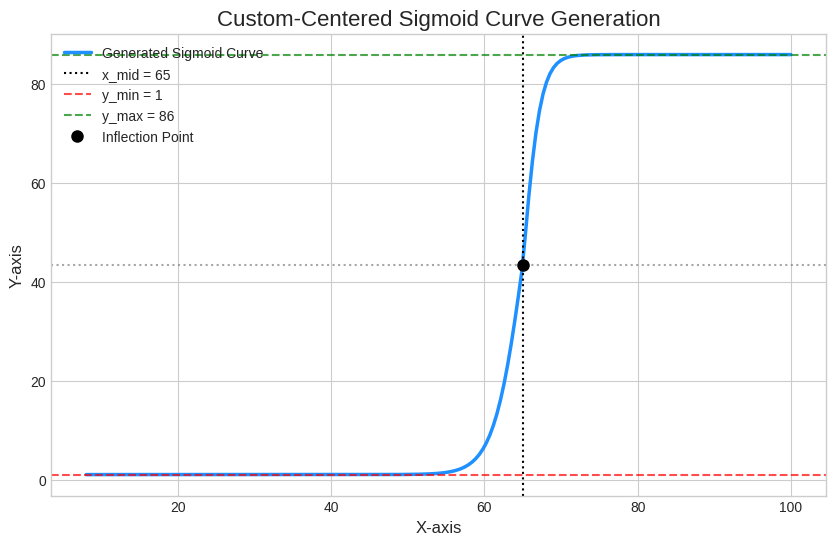

In [189]:
# --- 1. Setup Parameters ---
# Define the range for our x-axis
x_values = np.linspace(8, 100, 200)

# Define the properties of our desired sigmoid curve
y_target_min = 1
y_target_max = 86
x_mid_point = 65  # The inflection point of the curve
steepness_factor = 5 # A slightly sharper curve

# --- 2. Generate the Sigmoid Data ---
# Use the function to calculate the y-values
y_sigmoid_values = manual_sigmoid(
    x=x_values,
    x_mid=x_mid_point,
    y_min=y_target_min,
    y_max=y_target_max,
    steepness=steepness_factor
)

# --- 3. Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the generated sigmoid curve
ax.plot(x_values, y_sigmoid_values, color='dodgerblue', linewidth=2.5, label='Generated Sigmoid Curve')

# Add visual aids to verify the function's behavior
ax.axvline(x=x_mid_point, color='k', linestyle=':', linewidth=1.5, label=f'x_mid = {x_mid_point}')
ax.axhline(y=y_target_min, color='r', linestyle='--', alpha=0.7, label=f'y_min = {y_target_min}')
ax.axhline(y=y_target_max, color='g', linestyle='--', alpha=0.7, label=f'y_max = {y_target_max}')
mid_y_val = (y_target_min + y_target_max) / 2
ax.axhline(y=mid_y_val, color='gray', linestyle=':', alpha=0.7)
ax.plot(x_mid_point, mid_y_val, 'ko', markersize=8, label='Inflection Point')


# Formatting
ax.set_title('Custom-Centered Sigmoid Curve Generation', fontsize=16)
ax.set_xlabel('X-axis', fontsize=12)
ax.set_ylabel('Y-axis', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True)
plt.show()

In [190]:
conf_sigm = manual_sigmoid(
    x=X1[:,0],
    x_mid=80,
    y_min=0,
    y_max=10,
    steepness = 1.0)
conf_sigm

array([0.33569223, 0.74467945, 1.27861566, 1.82425524, 6.49568457,
       9.39508678, 9.87733869, 9.97527377, 0.02472623, 0.47425873,
       5.        , 8.47391335, 9.68585629, 9.94192942, 0.14774032,
       0.23660578, 0.35571189, 0.62973356, 1.6520487 , 4.55121108,
       6.09619785, 8.51772527, 9.2190898 , 9.82214541, 9.903258  ,
       0.02472623, 0.47425873, 5.        , 8.47391335, 9.68585629,
       9.94192942])